# Integração e Exploração de um Dataset Multiorigem

## Relação entre Taxa de Desemprego e Ataques Terroristas ao Longo do Tempo

**Autores:** Rafael Teixeira e Tiago Cardoso  
**Unidade curricular:** Data Analysis  
**Universidade:** Universidade Fernando Pessoa

## 1. Introdução

O terrorismo é um fenómeno global com impacto na segurança pública, estabilidade política e desenvolvimento económico. Muitas vezes, fatores económicos como desemprego, pobreza ou instabilidade financeira são discutidos como possíveis elementos associados a contextos de violência e conflito.

Este projeto analisa se existe relação entre a taxa de desemprego e o número de ataques terroristas registados por país e por ano. Para isso, foram integradas duas fontes de dados independentes: a **Global Terrorism Database (GTD)** e os indicadores de desemprego do **World Bank Open Data**.

O objetivo não é provar causalidade, mas sim explorar padrões, tendências e possíveis relações entre variáveis através de técnicas de integração, limpeza, análise exploratória e visualização de dados.

## 2. Questão de Investigação

**Existe uma relação entre a taxa de desemprego e o número de ataques terroristas entre países ao longo do tempo?**

Esta questão é adequada ao projeto porque exige a integração de dados de fontes diferentes, com uma chave comum baseada em **país** e **ano**.

## 3. Fontes de Dados

### Dataset 1 — Global Terrorism Database (GTD)

A GTD contém registos de ataques terroristas a nível mundial. Cada linha representa um evento terrorista individual.

Variáveis principais utilizadas:
- `country_txt`: país onde ocorreu o ataque;
- `region_txt`: região geográfica;
- `iyear`: ano do ataque;
- `nkill`: número de vítimas mortais;
- `attacktype1_txt`: tipo de ataque;
- `gname`: grupo responsável, quando identificado.

### Dataset 2 — World Bank Open Data

Foi utilizado o indicador **Unemployment, total (% of total labor force)**, que representa a taxa de desemprego como percentagem da força de trabalho total.

Variáveis principais utilizadas:
- `Country Name`: país;
- anos entre 1960 e 2025;
- valor da taxa de desemprego por país e ano.

### Limitações iniciais das fontes

Apesar de ambas as fontes serem credíveis, existem limitações importantes. Alguns países podem ter subnotificação de ataques terroristas, especialmente em contextos de conflito ou baixa capacidade institucional. Além disso, nem todos os países possuem dados económicos completos para todos os anos.

## 4. Importação dos Dados

Nesta secção são carregados os dois datasets. O ficheiro GTD usa a codificação `latin1`, por isso essa opção é definida explicitamente. Também é utilizado `low_memory=False` para evitar avisos relacionados com tipos de dados mistos.

In [1]:
# Importar bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Melhorar o tamanho padrão dos gráficos
plt.rcParams["figure.figsize"] = (10, 5)

# Carregar o dataset de terrorismo (GTD)
gtd = pd.read_csv(
    "globalterrorismdb_0718dist.csv",
    encoding="latin1",
    low_memory=False
)

# Carregar o dataset do World Bank.
# O código tenta primeiro o nome usado no computador local; se não existir, tenta o nome com (1).
try:
    unemployment = pd.read_csv(
        "API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_115692.csv",
        skiprows=4
    )
except FileNotFoundError:
    unemployment = pd.read_csv(
        "API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_115692(1).csv",
        skiprows=4
    )

print("Dimensão do dataset GTD:", gtd.shape)
print("Dimensão do dataset World Bank:", unemployment.shape)

display(gtd.head())
display(unemployment.head())

Dimensão do dataset GTD: (181691, 135)
Dimensão do dataset World Bank: (266, 71)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.214915,7.244843,7.459106,7.974302,8.407412,7.869470,7.676548,7.571697,7.539234,NaN
2,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,11.192000,11.187000,11.710000,12.006000,14.100000,14.008000,13.687000,13.351000,NaN
3,Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.283996,4.334377,4.390764,4.795318,4.666634,3.593354,3.200801,3.172421,3.190552,NaN
4,Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,16.617000,16.602000,16.497000,16.696000,15.799000,14.124000,14.051000,14.020000,14.108000,NaN


## 5. Integração dos Dados

Os datasets originais possuem estruturas diferentes. A GTD está ao nível do evento individual, enquanto o World Bank está em formato largo, com uma coluna para cada ano.

Para integrar os dados foram seguidos estes passos:

1. Agregar os ataques terroristas por país, região e ano;
2. Calcular o número total de ataques e o número total de vítimas mortais;
3. Transformar os dados do World Bank de formato largo para formato longo com `melt()`;
4. Fazer o `merge()` usando `country` e `year` como chaves comuns.

Esta etapa é central no projeto, pois cria uma tabela única que permite analisar terrorismo e desemprego em conjunto.

In [2]:
# Selecionar apenas as colunas relevantes da GTD
gtd_selected = gtd[[
    "country_txt",
    "region_txt",
    "iyear",
    "nkill",
    "attacktype1_txt",
    "gname"
]].copy()

# Substituir valores em falta em nkill por 0.
# Justificação: quando o número de mortes não está registado, assume-se 0 para permitir agregação conservadora.
gtd_selected["nkill"] = gtd_selected["nkill"].fillna(0)

# Agregar ataques por país, região e ano
attacks = (
    gtd_selected
    .groupby(["country_txt", "region_txt", "iyear"])
    .agg(
        attacks=("iyear", "size"),
        total_deaths=("nkill", "sum"),
        avg_deaths_per_attack=("nkill", "mean")
    )
    .reset_index()
)

attacks = attacks.rename(columns={
    "country_txt": "country",
    "region_txt": "region",
    "iyear": "year"
})

# Identificar colunas que correspondem a anos no dataset do World Bank
year_columns = [col for col in unemployment.columns if str(col).isdigit()]

# Transformar o dataset do World Bank de formato largo para formato longo
unemployment_long = unemployment.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_columns,
    var_name="year",
    value_name="unemployment_rate"
)

unemployment_long = unemployment_long.rename(columns={
    "Country Name": "country"
})

unemployment_long["year"] = unemployment_long["year"].astype(int)

# Fazer merge dos datasets por país e ano
df = pd.merge(
    attacks,
    unemployment_long,
    on=["country", "year"],
    how="inner"
)

print("Dimensão após integração:", df.shape)
display(df.head())

Dimensão após integração: (3105, 8)


,country,region,year,attacks,total_deaths,avg_deaths_per_attack,Country Code,unemployment_rate
0,Afghanistan,South Asia,1973,1,0.0,0.000000,AFG,NaN
1,Afghanistan,South Asia,1979,3,53.0,17.666667,AFG,NaN
2,Afghanistan,South Asia,1987,1,0.0,0.000000,AFG,NaN
3,Afghanistan,South Asia,1988,11,128.0,11.636364,AFG,NaN
4,Afghanistan,South Asia,1989,10,10.0,1.000000,AFG,NaN


## 6. Análise de Valores em Falta

O enunciado pede não apenas identificar valores em falta, mas também analisar possíveis padrões. Por isso, nesta secção são observados:

- o número de valores em falta por variável;
- a percentagem de valores em falta;
- a evolução dos valores em falta ao longo do tempo.

Como a variável `unemployment_rate` é essencial para a questão de investigação, os registos sem esta informação foram removidos. A imputação por média ou mediana não foi usada porque o desemprego varia muito entre países e períodos históricos. Substituir valores em falta poderia criar padrões artificiais e enviesar a análise.

Valores em falta por coluna:


,missing_count,missing_percent
country,0,0.00
region,0,0.00
year,0,0.00
attacks,0,0.00
total_deaths,0,0.00
avg_deaths_per_attack,0,0.00
Country Code,0,0.00
unemployment_rate,1100,35.43


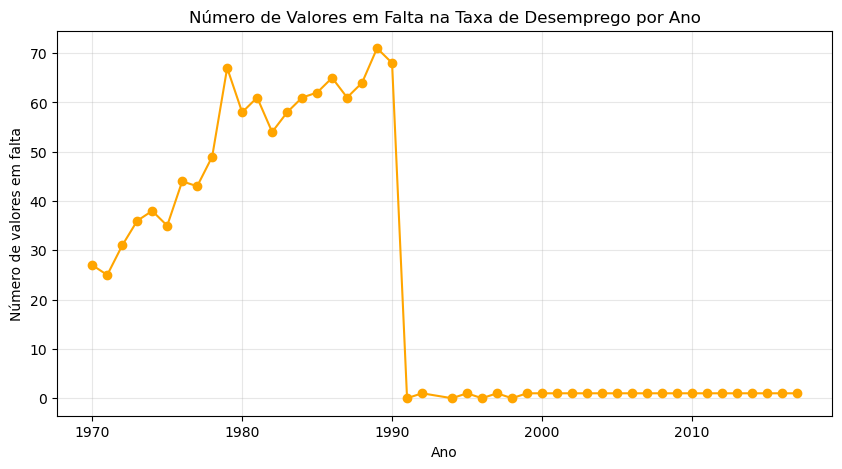

Dimensão antes da limpeza: (3105, 8)
Dimensão após remover valores em falta: (2005, 8)
Número de linhas removidas: 1100


,country,region,year,attacks,total_deaths,avg_deaths_per_attack,Country Code,unemployment_rate
6,Afghanistan,South Asia,1991,30,68.0,2.266667,AFG,7.972
7,Afghanistan,South Asia,1992,36,49.0,1.361111,AFG,7.958
8,Afghanistan,South Asia,1994,9,22.0,2.444444,AFG,7.883
9,Afghanistan,South Asia,1995,6,5.0,0.833333,AFG,7.868
10,Afghanistan,South Asia,1996,4,31.0,7.750000,AFG,7.878


In [3]:
# Contagem de valores em falta por coluna
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

print("Valores em falta por coluna:")
display(missing_table)

# Analisar valores em falta por ano na variável unemployment_rate
missing_by_year = (
    df.assign(missing_unemployment=df["unemployment_rate"].isnull())
    .groupby("year")["missing_unemployment"]
    .sum()
)

plt.figure(figsize=(10,5))
plt.plot(missing_by_year.index, missing_by_year.values, marker="o", color="orange")
plt.title("Número de Valores em Falta na Taxa de Desemprego por Ano")
plt.xlabel("Ano")
plt.ylabel("Número de valores em falta")
plt.grid(True, alpha=0.3)
plt.show()

# Remover linhas com valores em falta
original_shape = df.shape
df_clean = df.dropna().copy()
clean_shape = df_clean.shape

print("Dimensão antes da limpeza:", original_shape)
print("Dimensão após remover valores em falta:", clean_shape)
print("Número de linhas removidas:", original_shape[0] - clean_shape[0])

display(df_clean.head())

### Interpretação dos valores em falta

Foram identificados valores em falta principalmente na variável de desemprego. Isto pode acontecer porque alguns países ou anos não possuem registos económicos completos no World Bank.

A decisão de usar `dropna()` foi tomada porque a taxa de desemprego é a variável explicativa principal. Como a análise depende diretamente desta variável, imputar valores poderia introduzir estimativas artificiais e reduzir a fiabilidade dos resultados.

## 7. Deteção e Análise de Outliers

Os outliers foram analisados através de boxplot e do método **IQR (Interquartile Range)**. Este método identifica valores muito afastados da maioria das observações.

Neste projeto, os outliers não foram removidos, porque podem representar períodos reais de forte atividade terrorista em certos países. Removê-los poderia eliminar precisamente alguns dos casos mais relevantes para compreender o fenómeno.

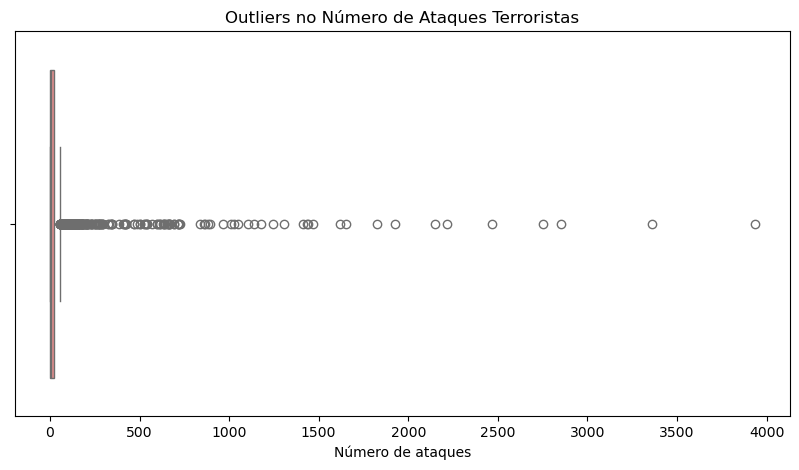

Q1: 2.0
Q3: 24.0
IQR: 22.0
Limite superior: 57.0
Número de outliers: 294


,country,region,year,attacks,unemployment_rate,total_deaths
1363,Iraq,Middle East & North Africa,2014,3933,10.590,13965.0
1365,Iraq,Middle East & North Africa,2016,3360,10.820,12207.0
1362,Iraq,Middle East & North Africa,2013,2852,9.222,7041.0
1364,Iraq,Middle East & North Africa,2015,2751,10.865,8885.0
1366,Iraq,Middle East & North Africa,2017,2466,13.020,6476.0
2220,Pakistan,South Asia,2013,2215,2.954,2875.0
2221,Pakistan,South Asia,2014,2151,1.827,2413.0
29,Afghanistan,South Asia,2015,1928,9.032,6216.0
28,Afghanistan,South Asia,2014,1824,7.915,5414.0
2219,Pakistan,South Asia,2012,1654,3.667,2784.0


In [4]:
# Boxplot para visualizar outliers no número de ataques
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["attacks"], color="lightcoral")
plt.title("Outliers no Número de Ataques Terroristas")
plt.xlabel("Número de ataques")
plt.show()

# Calcular limites pelo método IQR
Q1 = df_clean["attacks"].quantile(0.25)
Q3 = df_clean["attacks"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["attacks"] < lower_bound) |
    (df_clean["attacks"] > upper_bound)
].copy()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite superior:", upper_bound)
print("Número de outliers:", len(outliers))

# Mostrar os 10 casos mais extremos
top_outliers = outliers.sort_values("attacks", ascending=False).head(10)
display(top_outliers[["country", "region", "year", "attacks", "unemployment_rate", "total_deaths"]])

### Interpretação dos outliers

A presença de outliers mostra que a maioria dos países/anos tem poucos ataques, mas alguns casos apresentam níveis muito elevados de terrorismo. Estes valores extremos são importantes porque podem corresponder a contextos históricos específicos, como guerras, conflitos internos ou forte instabilidade política.

Por este motivo, os outliers foram mantidos na análise. A sua remoção poderia tornar os gráficos mais simples, mas também reduziria a capacidade do projeto para representar eventos reais de grande intensidade.

## 8. Análise Exploratória dos Dados (EDA)

A análise exploratória permite compreender a estrutura do dataset final, observar a distribuição das variáveis e identificar padrões importantes.

Nesta secção são analisadas:

- estatísticas descritivas;
- concentração geográfica dos ataques;
- evolução temporal;
- relação entre desemprego, ataques e vítimas mortais.

In [5]:
# Estatísticas descritivas das principais variáveis numéricas
eda_summary = df_clean[[
    "attacks",
    "unemployment_rate",
    "total_deaths",
    "avg_deaths_per_attack"
]].describe()

display(eda_summary)

,attacks,unemployment_rate,total_deaths,avg_deaths_per_attack
count,2005.000000,2005.000000,2005.000000,2005.000000
mean,57.455362,7.574145,137.088778,2.229530
std,230.370999,5.471126,703.068429,5.655144
min,1.000000,0.170000,0.000000,0.000000
25%,2.000000,3.558000,0.000000,0.000000
50%,5.000000,6.325000,3.000000,0.613636
75%,24.000000,10.207000,31.000000,2.067961
max,3933.000000,31.840000,13965.000000,113.000000


### Interpretação das estatísticas descritivas

As estatísticas descritivas permitem observar que o número de ataques apresenta grande dispersão. Isto significa que existem muitos casos com poucos ataques e alguns casos com valores extremamente elevados.

A taxa de desemprego apresenta também variação entre países e anos, mas a dispersão dos ataques terroristas é bastante mais acentuada. Esta diferença sugere que o terrorismo é um fenómeno concentrado em determinados contextos geográficos e históricos.

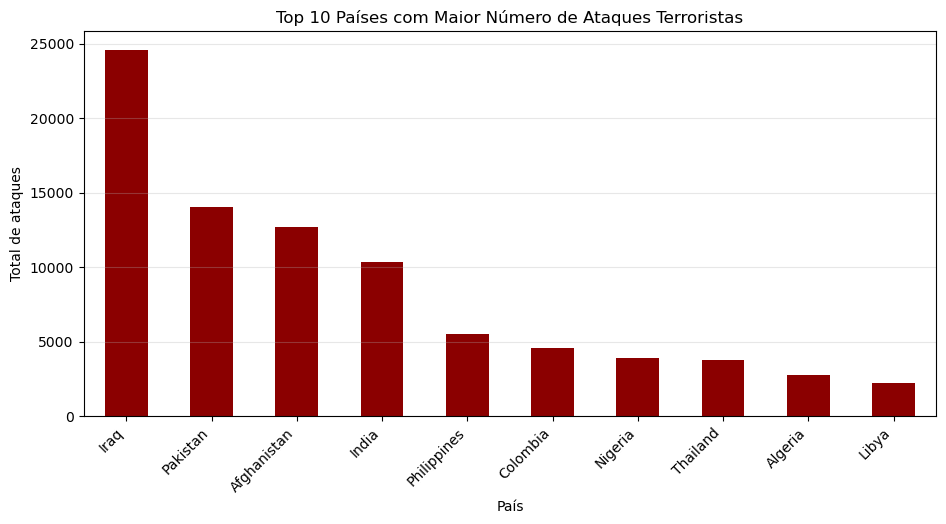

,country,total_attacks
0,Iraq,24600
1,Pakistan,14068
2,Afghanistan,12703
3,India,10359
4,Philippines,5546
5,Colombia,4587
6,Nigeria,3900
7,Thailand,3739
8,Algeria,2737
9,Libya,2241


In [6]:
# Top 10 países com maior número total de ataques no dataset integrado
top_countries = (
    df_clean.groupby("country")["attacks"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,5))
top_countries.plot(kind="bar", color="darkred")
plt.title("Top 10 Países com Maior Número de Ataques Terroristas")
plt.xlabel("País")
plt.ylabel("Total de ataques")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(top_countries.reset_index(name="total_attacks"))

### Interpretação por país

O gráfico dos países com mais ataques mostra que a atividade terrorista não está distribuída de forma uniforme. Pelo contrário, uma pequena parte dos países concentra uma proporção elevada dos ataques.

Esta análise é importante porque ajuda a perceber que uma correlação global entre desemprego e terrorismo pode esconder diferenças regionais ou nacionais muito fortes.

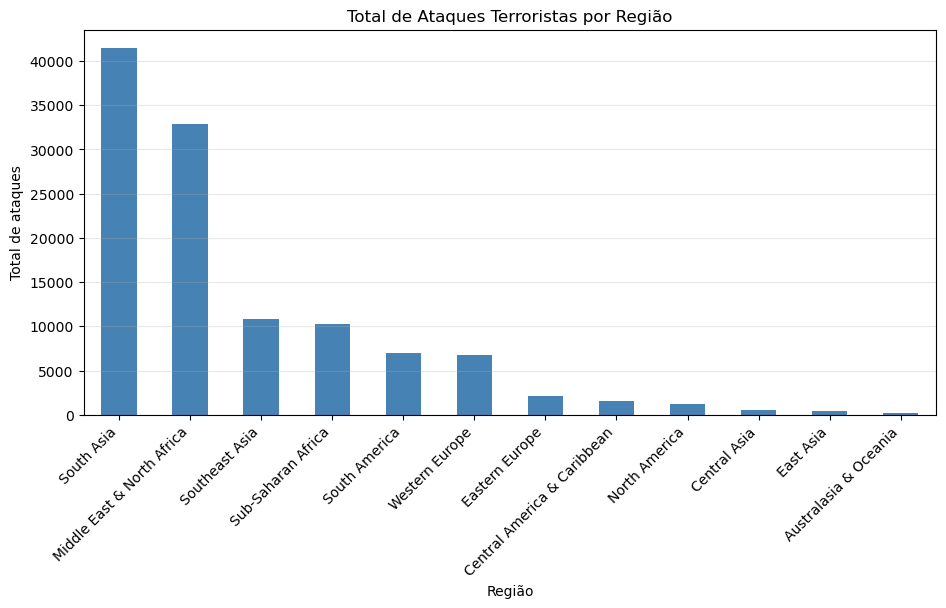

,region,total_attacks
0,South Asia,41451
1,Middle East & North Africa,32868
2,Southeast Asia,10809
3,Sub-Saharan Africa,10231
4,South America,7004
5,Western Europe,6788
6,Eastern Europe,2082
7,Central America & Caribbean,1610
8,North America,1265
9,Central Asia,528


In [7]:
# Ataques por região
region_attacks = (
    df_clean.groupby("region")["attacks"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11,5))
region_attacks.plot(kind="bar", color="steelblue")
plt.title("Total de Ataques Terroristas por Região")
plt.xlabel("Região")
plt.ylabel("Total de ataques")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(region_attacks.reset_index(name="total_attacks"))

### Interpretação por região

A análise regional permite compreender melhor a distribuição geográfica dos ataques. Algumas regiões apresentam níveis muito superiores de atividade terrorista, o que reforça a ideia de que fatores políticos, históricos e regionais podem ter um papel mais relevante do que o desemprego isoladamente.

## 9. Distribuição das Variáveis

Os histogramas permitem avaliar a forma da distribuição das variáveis principais. Esta análise ajuda a identificar assimetrias, concentração de valores e possíveis padrões anómalos.

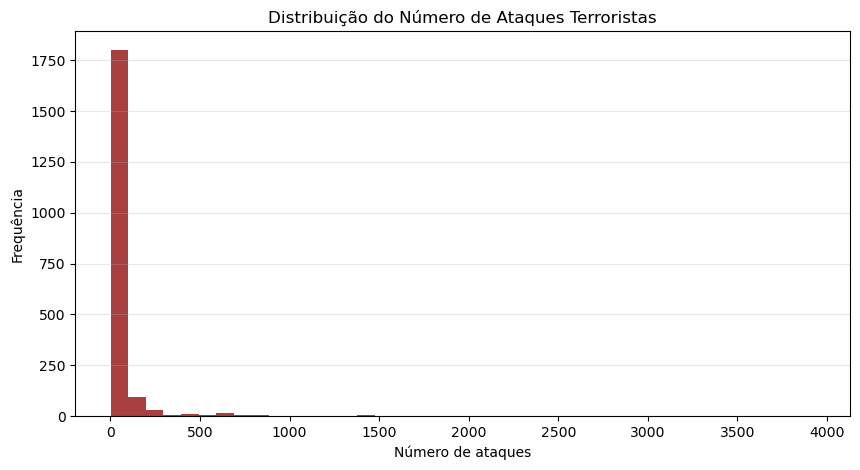

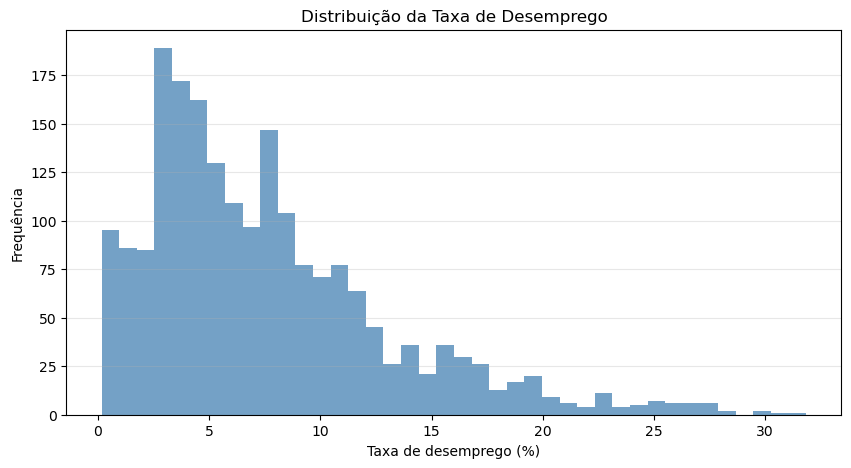

In [8]:
# Distribuição do número de ataques
plt.figure(figsize=(10,5))
plt.hist(df_clean["attacks"], bins=40, color="darkred", alpha=0.75)
plt.title("Distribuição do Número de Ataques Terroristas")
plt.xlabel("Número de ataques")
plt.ylabel("Frequência")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Distribuição da taxa de desemprego
plt.figure(figsize=(10,5))
plt.hist(df_clean["unemployment_rate"], bins=40, color="steelblue", alpha=0.75)
plt.title("Distribuição da Taxa de Desemprego")
plt.xlabel("Taxa de desemprego (%)")
plt.ylabel("Frequência")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Interpretação das distribuições

A distribuição do número de ataques é assimétrica, com muitos valores baixos e poucos valores extremamente altos. Isto confirma a existência de outliers e mostra que a atividade terrorista se concentra em determinados países e anos.

A distribuição da taxa de desemprego é mais equilibrada do que a dos ataques, embora também apresente valores elevados em alguns casos.

## 10. Correlações e Tendências

A correlação de Pearson mede a força de uma relação linear entre variáveis. No entanto, como o terrorismo é um fenómeno complexo, também foi calculada a correlação de Spearman, que pode captar relações monotónicas não necessariamente lineares.

Isto responde à limitação de usar apenas correlação linear.

In [9]:
# Correlação de Pearson: relação linear
pearson_corr = df_clean[["attacks", "unemployment_rate", "total_deaths"]].corr(method="pearson")
print("Correlação de Pearson:")
display(pearson_corr)

# Correlação de Spearman: relação monotónica, menos sensível a distribuições não normais
spearman_corr = df_clean[["attacks", "unemployment_rate", "total_deaths"]].corr(method="spearman")
print("Correlação de Spearman:")
display(spearman_corr)

Correlação de Pearson:


,attacks,unemployment_rate,total_deaths
attacks,1.000000,0.011246,0.871437
unemployment_rate,0.011246,1.000000,0.033615
total_deaths,0.871437,0.033615,1.000000


Correlação de Spearman:


,attacks,unemployment_rate,total_deaths
attacks,1.000000,0.016403,0.714536
unemployment_rate,0.016403,1.000000,-0.112421
total_deaths,0.714536,-0.112421,1.000000


### Interpretação da correlação

A correlação entre a taxa de desemprego e o número de ataques terroristas é muito fraca. Isto indica que, no dataset integrado, não existe evidência de uma relação forte entre estas duas variáveis.

A análise de Spearman foi incluída para verificar se poderia existir uma relação não-linear simples. Mesmo assim, a relação continua fraca, sugerindo que o desemprego, isoladamente, não explica adequadamente os padrões de terrorismo.

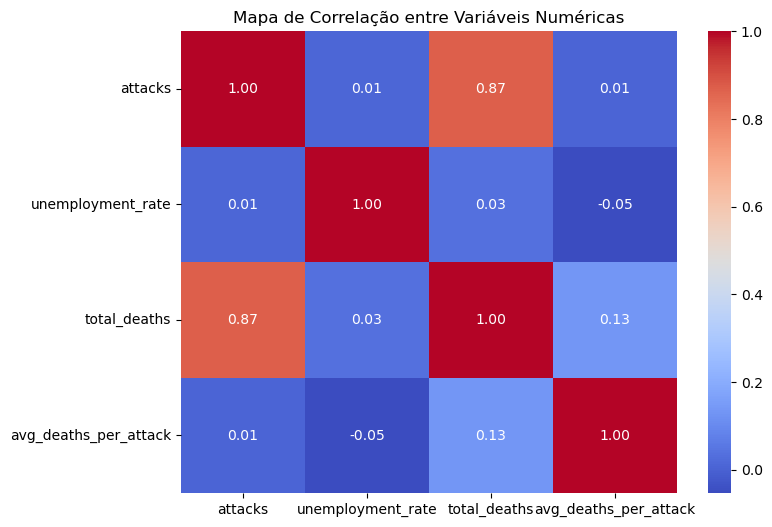

In [10]:
# Heatmap com mais variáveis do que apenas desemprego e ataques
plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean[["attacks", "unemployment_rate", "total_deaths", "avg_deaths_per_attack"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Mapa de Correlação entre Variáveis Numéricas")
plt.show()

## 11. Visualizações Principais

As visualizações seguintes ajudam a interpretar a relação entre desemprego e terrorismo, bem como as tendências temporais dos ataques e do desemprego médio.

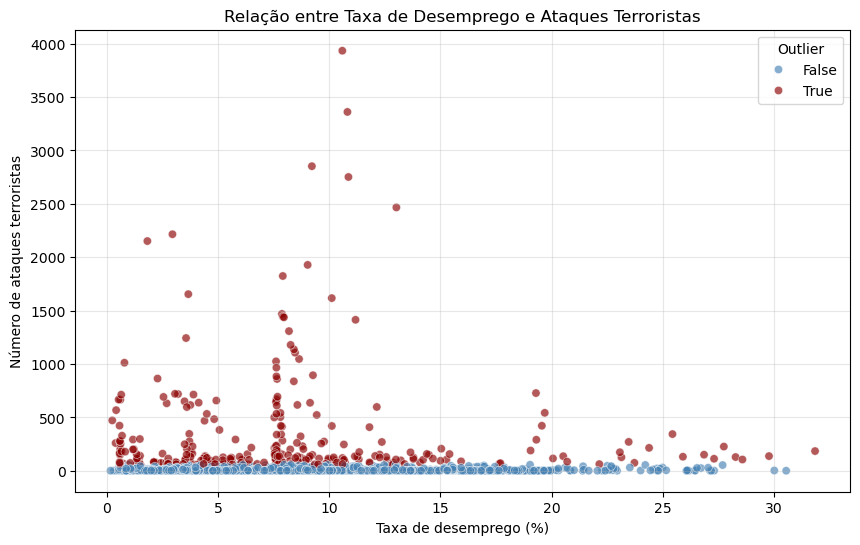

In [11]:
# Scatterplot com destaque visual para outliers
plot_df = df_clean.copy()
plot_df["is_outlier"] = plot_df["attacks"] > upper_bound

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=plot_df,
    x="unemployment_rate",
    y="attacks",
    hue="is_outlier",
    palette={False: "steelblue", True: "darkred"},
    alpha=0.65
)
plt.title("Relação entre Taxa de Desemprego e Ataques Terroristas")
plt.xlabel("Taxa de desemprego (%)")
plt.ylabel("Número de ataques terroristas")
plt.legend(title="Outlier")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretação do scatterplot

O scatterplot mostra que os pontos estão muito dispersos e não formam um padrão linear claro. Os pontos destacados como outliers representam países/anos com número de ataques muito superior à maioria das observações.

A ausência de um padrão claro reforça o resultado da correlação: o desemprego, sozinho, não parece explicar o número de ataques terroristas.

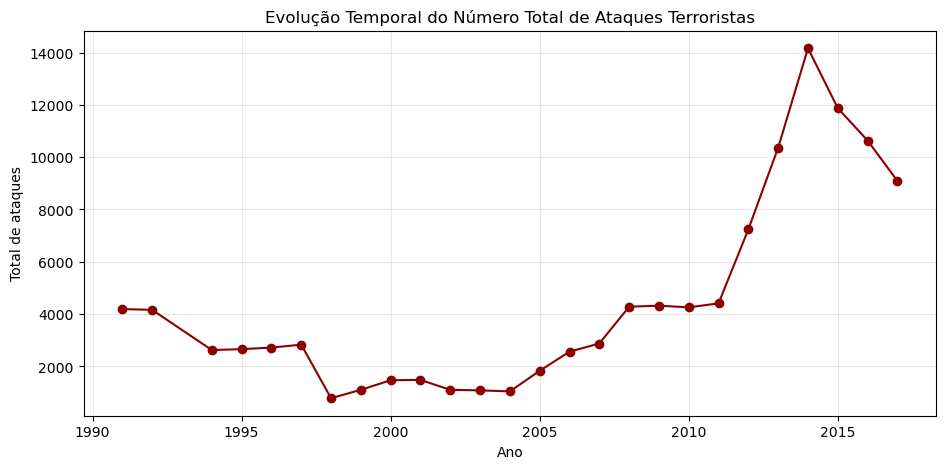

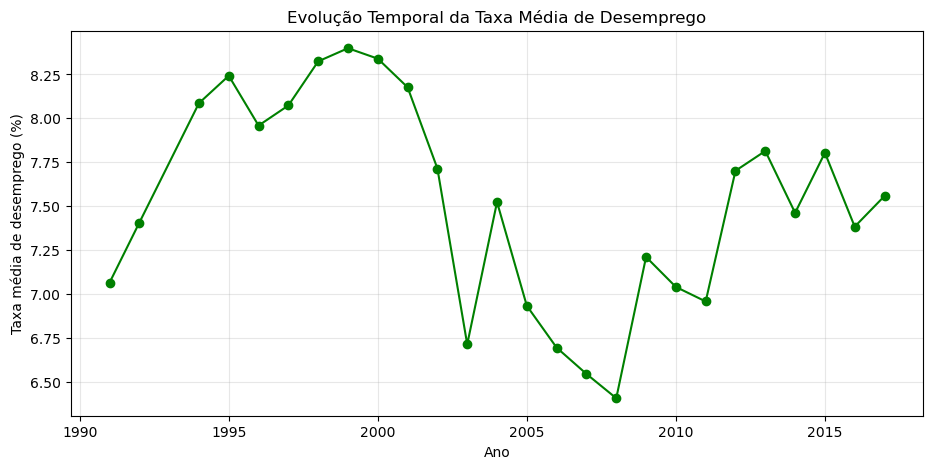

In [12]:
# Evolução temporal do total de ataques
attacks_yearly = df_clean.groupby("year")["attacks"].sum()

plt.figure(figsize=(11,5))
plt.plot(attacks_yearly.index, attacks_yearly.values, marker="o", color="darkred")
plt.title("Evolução Temporal do Número Total de Ataques Terroristas")
plt.xlabel("Ano")
plt.ylabel("Total de ataques")
plt.grid(True, alpha=0.3)
plt.show()

# Evolução temporal da taxa média de desemprego
unemployment_yearly = df_clean.groupby("year")["unemployment_rate"].mean()

plt.figure(figsize=(11,5))
plt.plot(unemployment_yearly.index, unemployment_yearly.values, marker="o", color="green")
plt.title("Evolução Temporal da Taxa Média de Desemprego")
plt.xlabel("Ano")
plt.ylabel("Taxa média de desemprego (%)")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretação das tendências temporais

A evolução temporal dos ataques mostra um aumento significativo após meados dos anos 2000, com um pico por volta de 2014–2015. Este padrão pode estar associado a conflitos regionais, guerras civis e crescimento de organizações terroristas em determinadas zonas do mundo.

A tendência da taxa média de desemprego não acompanha diretamente a evolução dos ataques terroristas, o que reforça a conclusão de que o desemprego não é, por si só, suficiente para explicar estes padrões.

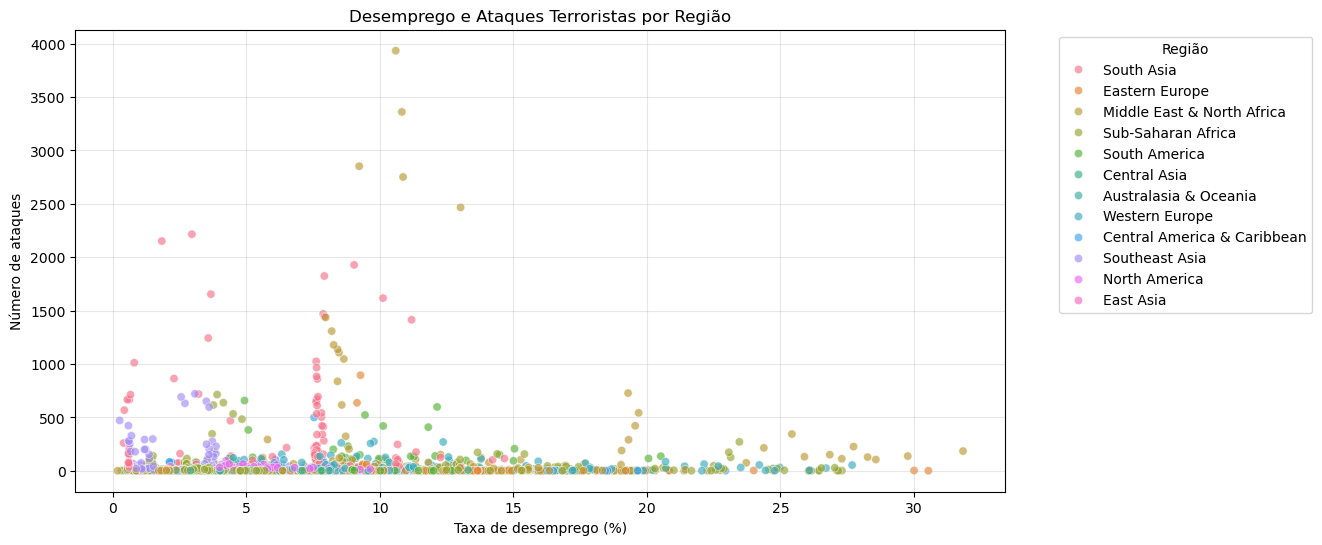

In [13]:
# Relação entre desemprego e ataques por região
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_clean,
    x="unemployment_rate",
    y="attacks",
    hue="region",
    alpha=0.65
)
plt.title("Desemprego e Ataques Terroristas por Região")
plt.xlabel("Taxa de desemprego (%)")
plt.ylabel("Número de ataques")
plt.legend(title="Região", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretação regional do scatterplot

Ao separar os pontos por região, percebe-se que a relação entre desemprego e terrorismo pode variar conforme o contexto geográfico. Isto sugere que uma análise global pode esconder padrões regionais específicos.

Esta visualização também prepara uma resposta importante para a defesa: uma análise futura poderia estudar cada região separadamente.

## 12. Conclusões

O objetivo deste projeto foi analisar se existe relação entre a taxa de desemprego e o número de ataques terroristas ao longo do tempo, integrando dados da Global Terrorism Database e do World Bank.

A análise mostrou que a correlação entre desemprego e ataques terroristas é muito fraca. Tanto a correlação de Pearson como a de Spearman indicam que não existe uma relação forte entre estas variáveis no dataset final.

A análise temporal revelou um aumento significativo dos ataques após 2005, com um pico por volta de 2014–2015. No entanto, este padrão não é acompanhado de forma direta pela evolução da taxa média de desemprego.

Os resultados sugerem que o desemprego, isoladamente, não é suficiente para explicar a atividade terrorista. Fatores como guerras, instabilidade política, conflitos regionais, fragilidade institucional e radicalização podem ter um papel mais importante.

Assim, a principal conclusão é que a integração de dados permitiu explorar a hipótese inicial, mas os resultados apontam para uma relação fraca entre desemprego e terrorismo.

## 13. Limitações

- A remoção de valores em falta reduziu o número de observações disponíveis.
- Alguns ataques terroristas podem estar subnotificados em determinados países.
- A análise considera apenas uma variável económica principal: desemprego.
- A agregação por país e ano pode esconder diferenças regionais dentro de cada país.
- Correlação não implica causalidade.
- O terrorismo é influenciado por múltiplos fatores políticos, sociais e históricos que não foram incluídos neste estudo.
- A correspondência entre nomes de países nos dois datasets pode excluir algumas observações devido a diferenças de nomenclatura.

## 14. Trabalho Futuro

Em trabalhos futuros, seria interessante incluir variáveis adicionais, como:

- PIB per capita;
- indicadores de estabilidade política;
- níveis de educação;
- desigualdade económica;
- dados sobre conflitos armados;
- indicadores de democracia ou liberdade política.

Também seria útil realizar análises por região ou por grupo de países, já que a relação entre fatores económicos e terrorismo pode variar consoante o contexto geográfico e político.